In [8]:
# Basic libraries for data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Word cloud for visualization
from wordcloud import WordCloud

# Set stopwords
STOPWORDS = set(stopwords.words('english'))

# Display settings for better visibility
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [4]:
# Load the dataset
data = pd.read_csv(r"Data\amazon_alexa.tsv", delimiter='\t', quoting=3)

# Basic data information
print(f"Dataset shape: {data.shape}")
print(f"\nColumn names: {data.columns.values}")
print(f"\nFirst 5 rows:")
data.head()

Dataset shape: (3150, 5)

Column names: <StringArray>
['rating', 'date', 'variation', 'verified_reviews', 'feedback']
Length: 5, dtype: str

First 5 rows:


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [5]:
# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Check for duplicates
print(f"\nNumber of duplicate rows: {data.duplicated().sum()}")

# Drop any rows with missing values (if any)
data_clean = data.dropna().copy()
print(f"\nDataset shape after cleaning: {data_clean.shape}")

# Check data types
print(f"\nData types:")
print(data_clean.dtypes)

Missing values in each column:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

Number of duplicate rows: 715

Dataset shape after cleaning: (3149, 5)

Data types:
rating              int64
date                  str
variation             str
verified_reviews      str
feedback            int64
dtype: object


In [6]:
# Create length column for review text analysis
data_clean['review_length'] = data_clean['verified_reviews'].apply(len)

# Create word count column
data_clean['word_count'] = data_clean['verified_reviews'].apply(lambda x: len(str(x).split()))

# Display the enhanced dataset
data_clean.head()

,rating,date,variation,verified_reviews,feedback,review_length,word_count
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13,3
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9,2
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197,38
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174,34
4,5,31-Jul-18,Charcoal Fabric,Music,1,5,1


Rating distribution:
rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64

Rating percentage distribution:
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


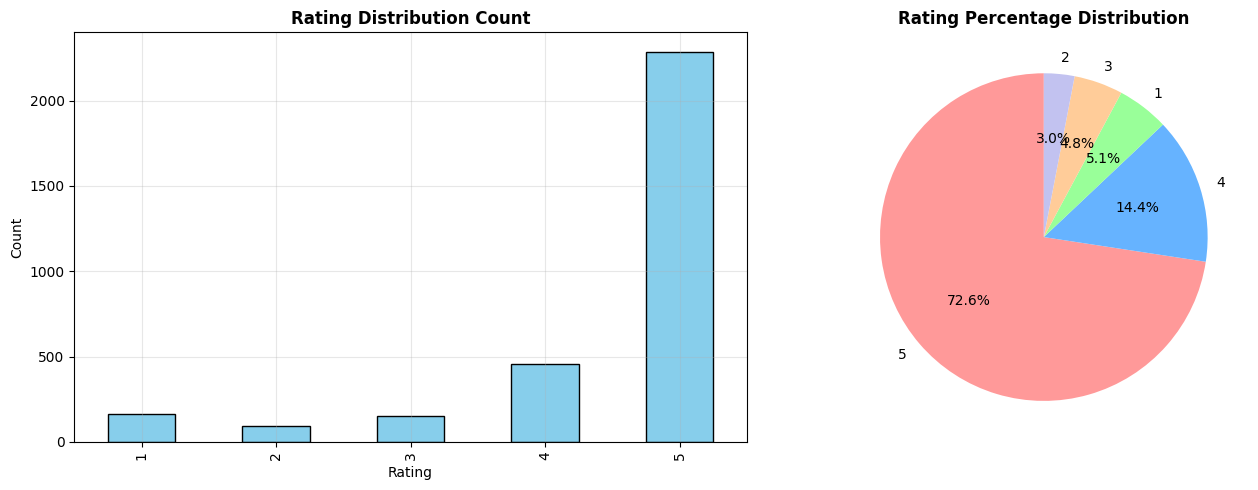

In [9]:
# Rating distribution
print("Rating distribution:")
print(data_clean['rating'].value_counts())
print(f"\nRating percentage distribution:")
print(round(data_clean['rating'].value_counts() / len(data_clean) * 100, 2))

# Bar plot for ratings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
data_clean['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Rating Distribution Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Pie chart
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
data_clean['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], 
                                          colors=colors, startangle=90)
axes[1].set_title('Rating Percentage Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Feedback distribution (0=Negative, 1=Positive):
feedback
1    2893
0     256
Name: count, dtype: int64

Feedback percentage distribution:
feedback
1    91.87
0     8.13
Name: count, dtype: float64


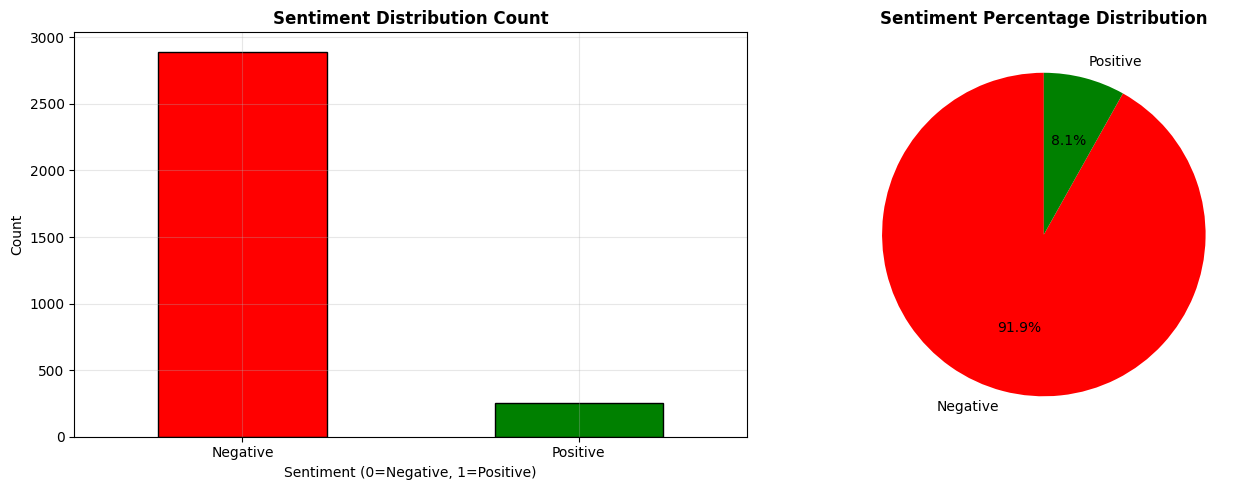


Example of Negative Review (Feedback=0):
"It's like Siri, in fact, Siri answers more accurately then Alexa.  I don't see a real need for it in my household, though it was a good bargain on prime day deals."

Example of Positive Review (Feedback=1):
Love my Echo!


In [10]:
# Feedback distribution
print("Feedback distribution (0=Negative, 1=Positive):")
print(data_clean['feedback'].value_counts())
print(f"\nFeedback percentage distribution:")
print(round(data_clean['feedback'].value_counts() / len(data_clean) * 100, 2))

# Visualizing feedback distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
data_clean['feedback'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'], edgecolor='black')
axes[0].set_title('Sentiment Distribution Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment (0=Negative, 1=Positive)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Negative', 'Positive'], rotation=0)
axes[0].grid(True, alpha=0.3)

# Pie chart
data_clean['feedback'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                                            colors=['red', 'green'], startangle=90,
                                            labels=['Negative', 'Positive'])
axes[1].set_title('Sentiment Percentage Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Show sample reviews
print("\nExample of Negative Review (Feedback=0):")
print(data_clean[data_clean['feedback'] == 0]['verified_reviews'].iloc[0])
print("\nExample of Positive Review (Feedback=1):")
print(data_clean[data_clean['feedback'] == 1]['verified_reviews'].iloc[0])

Rating vs Feedback cross-tabulation:
feedback    0     1
rating             
1         161     0
2          95     0
3           0   152
4           0   455
5           0  2286


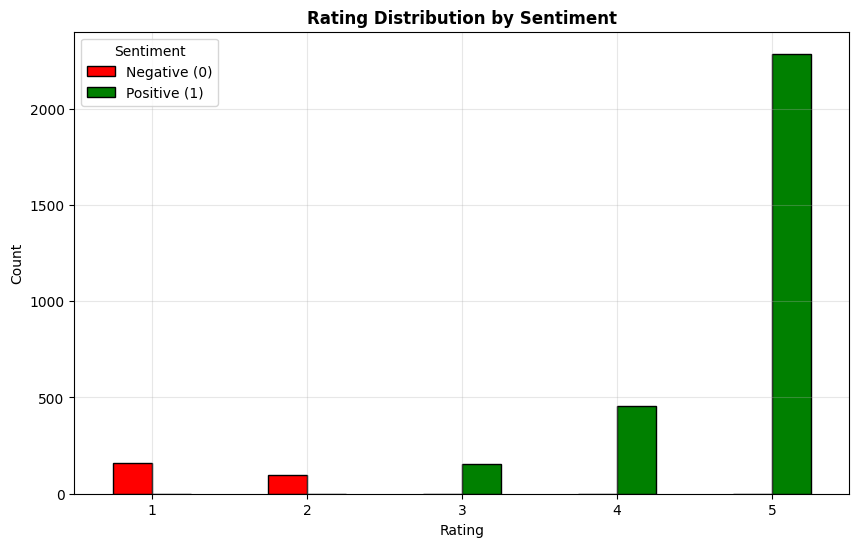


Insight: If rating is 1 or 2 → Feedback is Negative (0)
If rating is 3, 4, or 5 → Feedback is Positive (1)


In [11]:
# Cross-tabulation of rating and feedback
rating_feedback = pd.crosstab(data_clean['rating'], data_clean['feedback'])
print("Rating vs Feedback cross-tabulation:")
print(rating_feedback)

# Visualization
rating_feedback.plot(kind='bar', figsize=(10, 6), color=['red', 'green'], edgecolor='black')
plt.title('Rating Distribution by Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(['Negative (0)', 'Positive (1)'], title='Sentiment')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

# Analysis insight
print("\nInsight: If rating is 1 or 2 → Feedback is Negative (0)")
print("If rating is 3, 4, or 5 → Feedback is Positive (1)")

Top 10 Product Variations:
variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Name: count, dtype: int64

Top 10 Variations by Mean Rating:
variation
Walnut Finish                   4.888889
Oak Finish                      4.857143
Charcoal Fabric                 4.730233
Heather Gray Fabric             4.694268
Configuration: Fire TV Stick    4.591429
Black  Show                     4.490566
Black  Dot                      4.453488
White  Dot                      4.423913
Black  Plus                     4.370370
White  Plus                     4.358974
Name: rating, dtype: float64


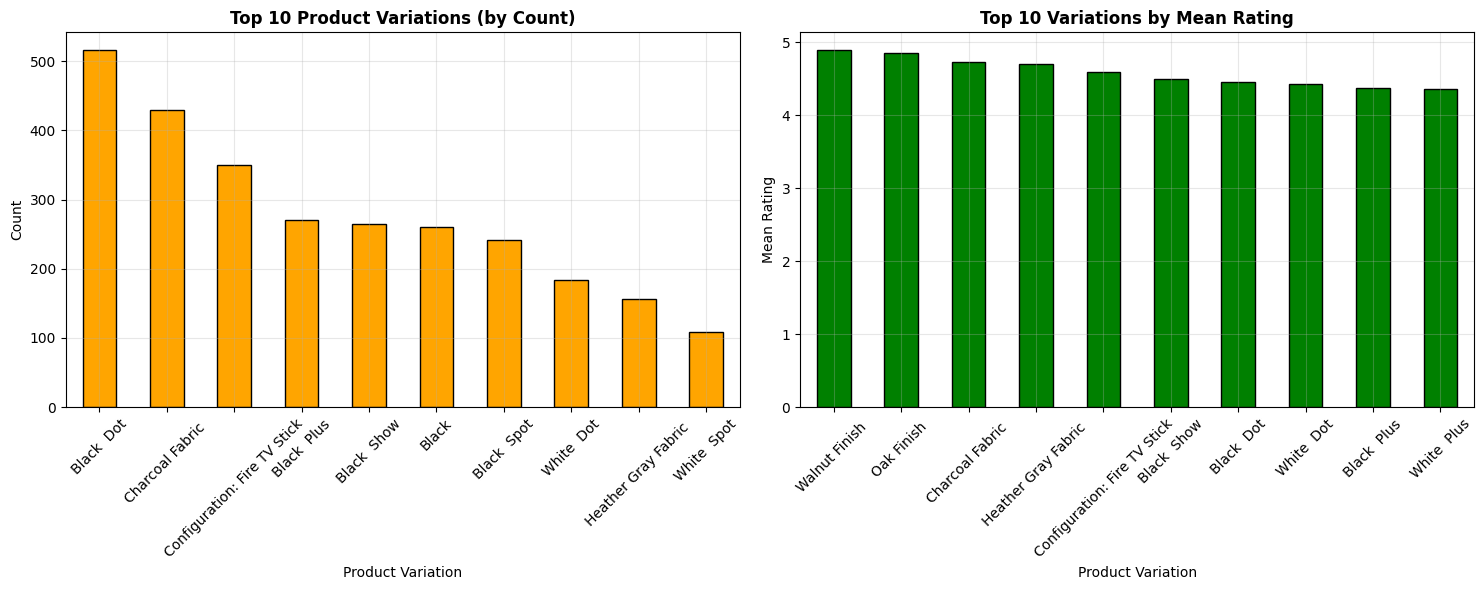

In [12]:
# Variation distribution (top 10)
variation_counts = data_clean['variation'].value_counts().head(10)
print("Top 10 Product Variations:")
print(variation_counts)

# Mean rating by variation
mean_rating_by_variation = data_clean.groupby('variation')['rating'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 Variations by Mean Rating:")
print(mean_rating_by_variation)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot - variation count
variation_counts.plot(kind='bar', ax=axes[0], color='orange', edgecolor='black')
axes[0].set_title('Top 10 Product Variations (by Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Variation')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Bar plot - mean rating by variation
mean_rating_by_variation.plot(kind='bar', ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Top 10 Variations by Mean Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product Variation')
axes[1].set_ylabel('Mean Rating')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Review Length Statistics:
count    3149.000000
mean      132.714513
std       182.541531
min         1.000000
25%        30.000000
50%        74.000000
75%       166.000000
max      2853.000000
Name: review_length, dtype: float64


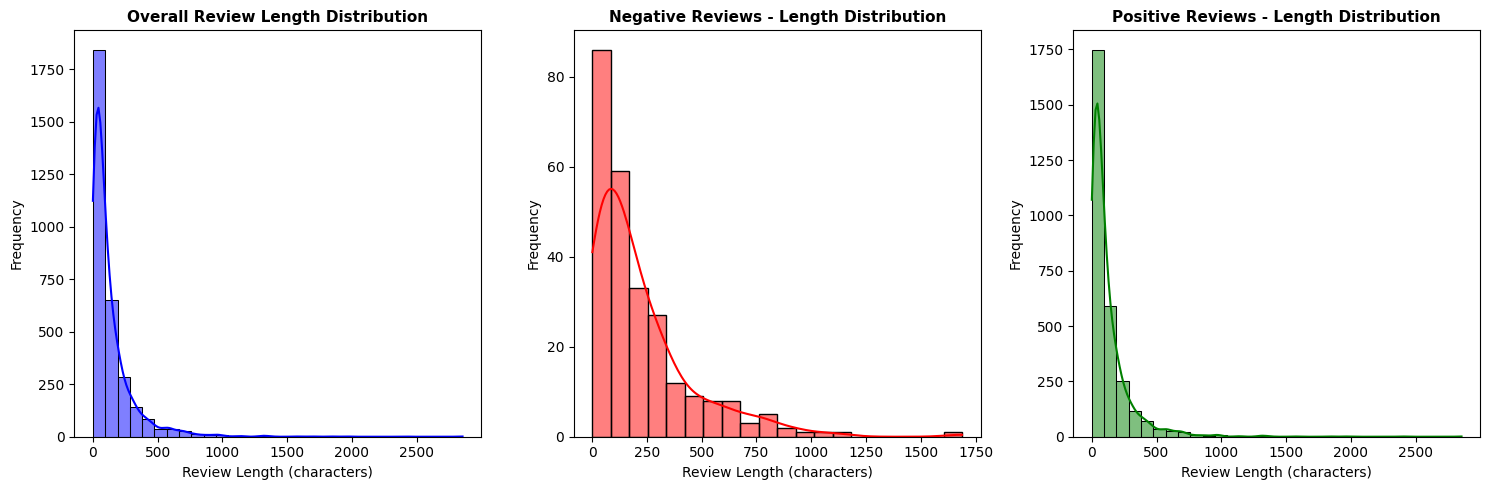


Average review length for Negative reviews: 216.8 characters
Average review length for Positive reviews: 125.3 characters


In [13]:
# Statistical summary of review lengths
print("Review Length Statistics:")
print(data_clean['review_length'].describe())

# Review length distribution by sentiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall distribution
sns.histplot(data_clean['review_length'], ax=axes[0], color='blue', bins=30, kde=True)
axes[0].set_title('Overall Review Length Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Frequency')

# Negative reviews only
neg_lengths = data_clean[data_clean['feedback'] == 0]['review_length']
sns.histplot(neg_lengths, ax=axes[1], color='red', bins=20, kde=True)
axes[1].set_title('Negative Reviews - Length Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Review Length (characters)')
axes[1].set_ylabel('Frequency')

# Positive reviews only
pos_lengths = data_clean[data_clean['feedback'] == 1]['review_length']
sns.histplot(pos_lengths, ax=axes[2], color='green', bins=30, kde=True)
axes[2].set_title('Positive Reviews - Length Distribution', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Review Length (characters)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Compare average lengths
print(f"\nAverage review length for Negative reviews: {neg_lengths.mean():.1f} characters")
print(f"Average review length for Positive reviews: {pos_lengths.mean():.1f} characters")

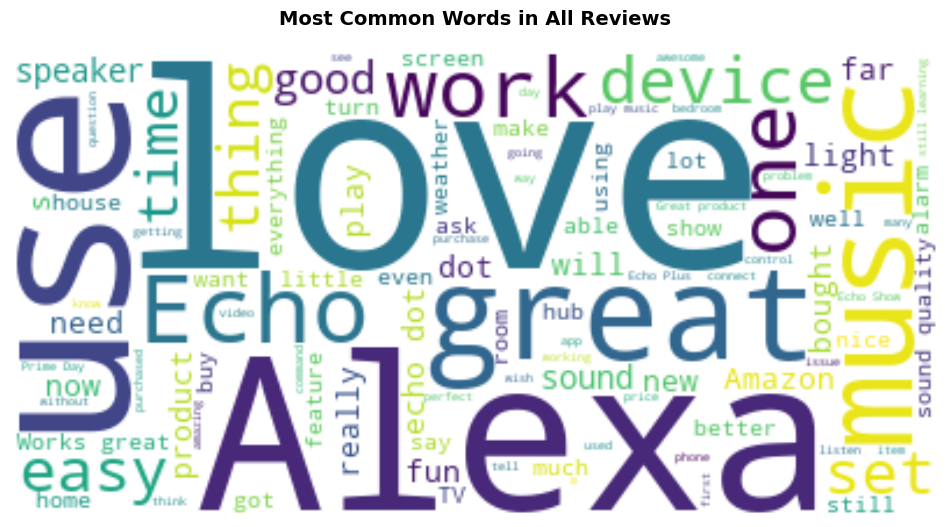

In [14]:
# Combine all reviews
all_reviews = " ".join([review for review in data_clean['verified_reviews']])

# Generate word cloud for all reviews
plt.figure(figsize=(12, 8))
wc = WordCloud(background_color='white', max_words=100, colormap='viridis')
wc.generate(all_reviews)
plt.imshow(wc, interpolation='bilinear')
plt.title('Most Common Words in All Reviews', fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

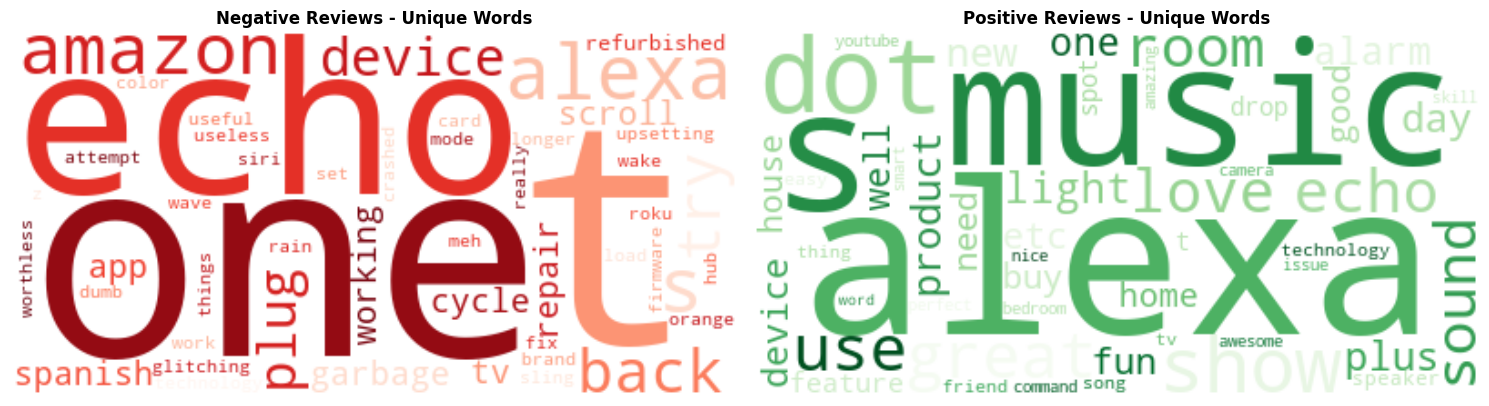

In [15]:
# Separate reviews by sentiment
negative_reviews = data_clean[data_clean['feedback'] == 0]['verified_reviews'].tolist()
positive_reviews = data_clean[data_clean['feedback'] == 1]['verified_reviews'].tolist()

# Combine reviews
neg_text = " ".join(negative_reviews).lower()
pos_text = " ".join(positive_reviews).lower()

# Split into words
neg_words = set(neg_text.split())
pos_words = set(pos_text.split())

# Find unique words
unique_negative = " ".join([word for word in neg_words if word not in pos_words])
unique_positive = " ".join([word for word in pos_words if word not in neg_words])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Negative reviews word cloud
wc_neg = WordCloud(background_color='white', max_words=50, colormap='Reds')
wc_neg.generate(unique_negative)
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Negative Reviews - Unique Words', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Positive reviews word cloud
wc_pos = WordCloud(background_color='white', max_words=50, colormap='Greens')
wc_pos.generate(unique_positive)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Positive Reviews - Unique Words', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Create a summary dataframe for insights
summary_stats = pd.DataFrame({
    'Metric': ['Total Reviews', 'Positive Reviews', 'Negative Reviews', 
               'Average Rating', 'Average Review Length'],
    'Value': [len(data_clean), 
              len(data_clean[data_clean['feedback']==1]),
              len(data_clean[data_clean['feedback']==0]),
              f"{data_clean['rating'].mean():.2f}",
              f"{data_clean['review_length'].mean():.1f} characters"]
})

print("=" * 50)
print("AMAZON ALEXA REVIEW ANALYSIS - KEY INSIGHTS")
print("=" * 50)
print(summary_stats.to_string(index=False))
print("\n" + "=" * 50)

# Additional insights
print("\n📊 KEY OBSERVATIONS:")
print(f"• {round(len(data_clean[data_clean['feedback']==1])/len(data_clean)*100,1)}% of reviews are positive")
print(f"• Most common rating is 5 stars ({data_clean['rating'].value_counts()[5]} reviews)")
print(f"• Best rated variation: {data_clean.groupby('variation')['rating'].mean().idxmax()} "
      f"({data_clean.groupby('variation')['rating'].mean().max():.2f} stars)")
print(f"• Most reviewed variation: {data_clean['variation'].value_counts().index[0]} "
      f"({data_clean['variation'].value_counts().values[0]} reviews)")

AMAZON ALEXA REVIEW ANALYSIS - KEY INSIGHTS
               Metric            Value
        Total Reviews             3149
     Positive Reviews             2893
     Negative Reviews              256
       Average Rating             4.46
Average Review Length 132.7 characters


📊 KEY OBSERVATIONS:
• 91.9% of reviews are positive
• Most common rating is 5 stars (2286 reviews)
• Best rated variation: Walnut Finish  (4.89 stars)
• Most reviewed variation: Black  Dot (516 reviews)
